In [11]:
import json
import pandas as pd

# Load class mapping
with open("artifacts/class_mapping.json", "r") as f:
    class_to_idx = json.load(f)

# Convert keys to int if needed
class_to_idx = {k: int(v) for k, v in class_to_idx.items()}
idx_to_class = {v: k for k, v in class_to_idx.items()}

# Load split
df = pd.read_csv("artifacts/data_split.csv")

train_df = df[df["split"] == "train"]
val_df = df[df["split"] == "test"]

train_paths = train_df["image_path"].tolist()
train_labels = train_df["label"].tolist()

test_paths = val_df["image_path"].tolist()
test_labels = val_df["label"].tolist()

In [12]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

IMAGE_SIZE = 224

eda_transforms = A.Compose([
    A.Resize(IMAGE_SIZE, IMAGE_SIZE),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

In [13]:
import cv2
from torch.utils.data import Dataset

class XrayDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            raise ValueError(f"Invalid image: {img_path}")

        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)

        label = self.labels[idx]

        if self.transform:
            image = self.transform(image=image)["image"]

        return image, label

In [14]:
train_dataset = XrayDataset(train_paths, train_labels, transform=eda_transforms)

##  1. Class Distribution

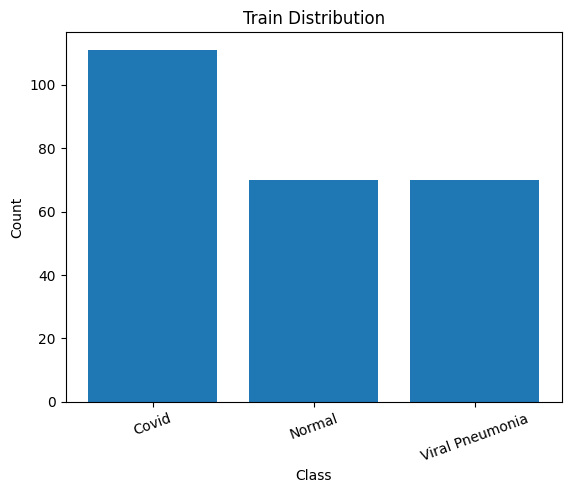

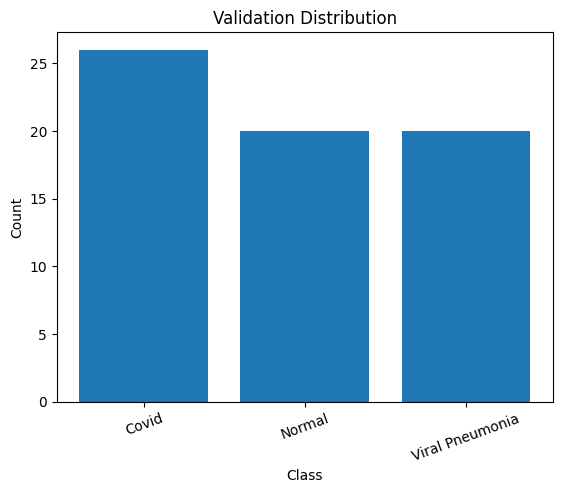

In [15]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_distribution(labels, title, class_names):
    counter = Counter(labels)

    names = [class_names[i] for i in counter.keys()]
    values = counter.values()

    plt.figure()
    plt.bar(names, values)
    plt.title(title)
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=20)
    plt.show()

idx_to_class = {v: k for k, v in class_to_idx.items()}

plot_distribution(train_labels, "Train Distribution", idx_to_class)
plot_distribution(test_labels, "Validation Distribution", idx_to_class)

## 2. Visualize Sample Images

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].


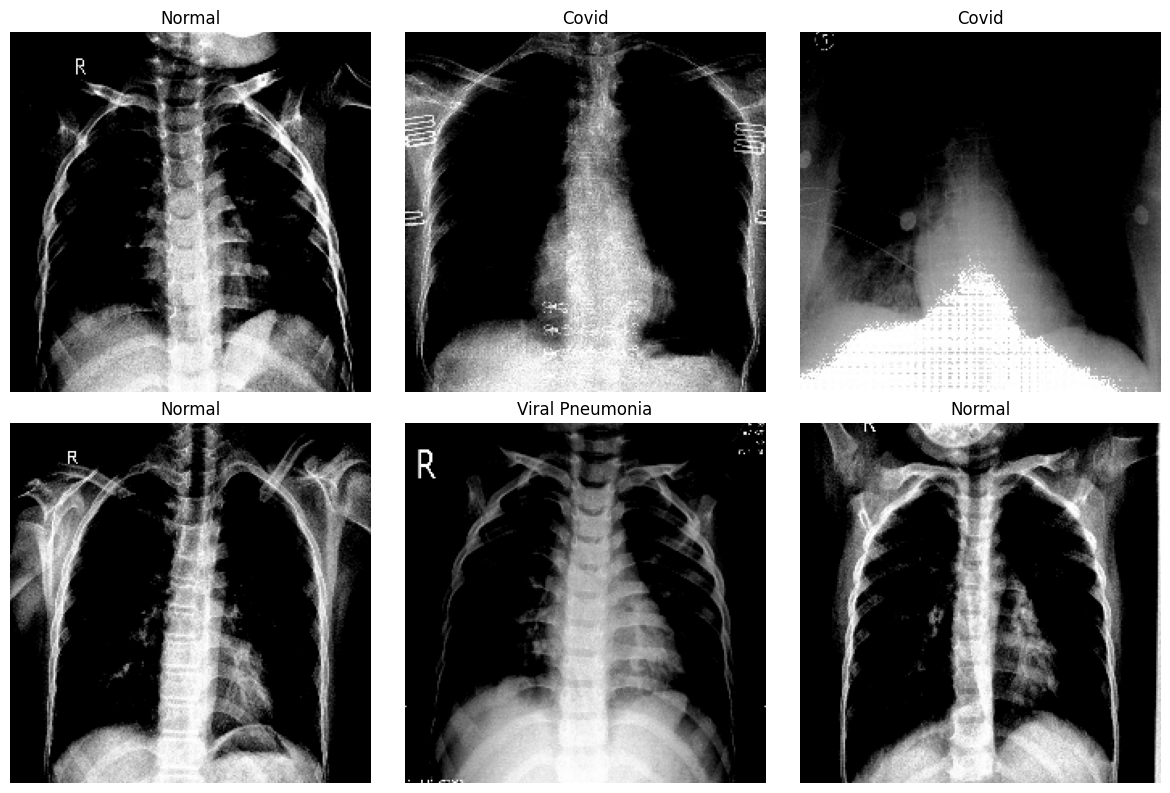

In [16]:
import random

def show_samples(dataset, class_names, num_images=6):
    plt.figure(figsize=(12, 8))

    indices = random.sample(range(len(dataset)), num_images)

    for i, idx in enumerate(indices):
        image, label = dataset[idx]
        image = image.permute(1, 2, 0).numpy()

        plt.subplot(2, 3, i+1)
        plt.imshow(image)
        plt.title(class_names[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_samples(train_dataset, idx_to_class)

## 3. Check Image Sizes

In [17]:
sizes = []
all_paths = train_paths + test_paths

for path in all_paths[:100]:  # sample for speed
    img = cv2.imread(path)
    if img is not None:
        sizes.append(img.shape[:2])

print("Sample image sizes:", sizes[:10])

Sample image sizes: [(4032, 3024), (557, 556), (2336, 2836), (1668, 1641), (1703, 1690), (1447, 1884), (1674, 1743), (2953, 3604), (1710, 1708), (2840, 2972)]


## 4. Pixel Distribution

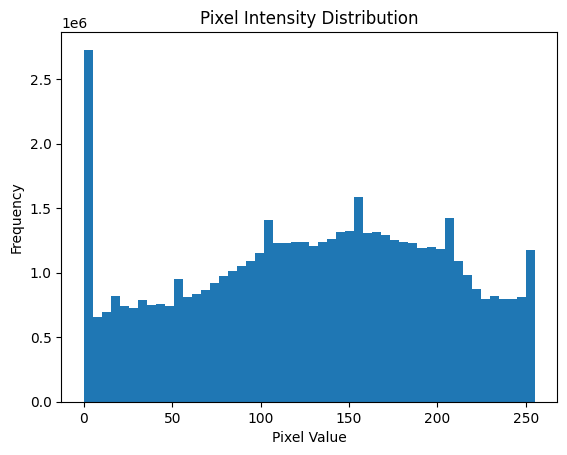

In [18]:
import numpy as np
pixels = []
sample_paths = random.sample(all_paths, 20)  # small sample

for path in sample_paths:
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is not None:
        pixels.append(img.flatten())

# Combine safely
pixels = np.concatenate(pixels)

# Plot histogram
plt.figure()
plt.hist(pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()